### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [7]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="llama-3.1-8b-instant")
llm_groq.invoke("Hey I am Krish and i like to play cricket")

AIMessage(content='Hi Krish, nice to meet you. Cricket is a fantastic sport, and there are many interesting aspects to it. Are you a professional cricketer, or do you play for fun? Do you have a favorite team or player?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 45, 'total_tokens': 93, 'completion_time': 0.081526487, 'prompt_time': 0.002073656, 'queue_time': 0.050480064, 'total_time': 0.083600143}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e32974efee', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--d75eefc9-34fd-4c3b-9016-a59ce36988f1-0', usage_metadata={'input_tokens': 45, 'output_tokens': 48, 'total_tokens': 93})

In [8]:
def superbot(state:State):
    return {"messages":llm_groq.invoke(state['messages'])}

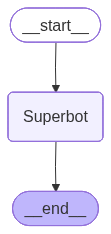

In [10]:
graph=StateGraph(State)

#nodes
graph.add_node("Superbot",superbot)

#edges
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder=graph.compile()

#View
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [16]:
#Invocation

result=graph_builder.invoke({'messages':"Hi, My name is Rishi and I like cricket."})

print(result['messages'][-1].content)  #Get just the last message's content

Hello Rishi. Nice to meet you. Cricket is a fantastic sport. Are you a fan of any particular team or player? Do you enjoy watching test matches or limited-overs formats like ODIs and T20s?


### Streming the responses

In [13]:
for event in graph_builder.stream({"messages":"Hello My name is Rishi"}):
    print(event)

{'Superbot': {'messages': AIMessage(content="Hello Rishi, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 41, 'total_tokens': 68, 'completion_time': 0.028454845, 'prompt_time': 0.001872619, 'queue_time': 0.054553401, 'total_time': 0.030327464}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e32974efee', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--0d24cd27-bcd9-42cf-b917-735de6eade7b-0', usage_metadata={'input_tokens': 41, 'output_tokens': 27, 'total_tokens': 68})}}
